Importing the pandas to our code to read the csv file and the df.head() is used to get the first 5 lines of the code for understanding the dataset and its data.

In [1]:
import pandas as pd
df = pd.read_csv("UberDataset.csv")
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [2]:
df["START_DATE"] = pd.to_datetime(df["START_DATE"], errors="coerce")

Why errors="coerce"? because our dataset contains some missing values. Now Pandas converts them into NaT (Not a Time).

In [3]:
df["Hour"] = df["START_DATE"].dt.hour

Here we extract the hour from the start date of the data set. which helps us in the future for the analysis of the particular data.

In [5]:
df["Day"] = df["START_DATE"].dt.day_name()
df[["START_DATE", "Day"]].head()

,START_DATE,Day
0,2016-01-01 21:11:00,Friday
1,2016-01-02 01:25:00,Saturday
2,2016-01-02 20:25:00,Saturday
3,2016-01-05 17:31:00,Tuesday
4,2016-01-06 14:42:00,Wednesday


In this step we gonna extract the day name from the dataset. And then we extracted the top 5 rows using the head() to check the results.

In [6]:
df["Month"] = df["START_DATE"].dt.month_name()
df[["START_DATE", "Month"]].head()

,START_DATE,Month
0,2016-01-01 21:11:00,January
1,2016-01-02 01:25:00,January
2,2016-01-02 20:25:00,January
3,2016-01-05 17:31:00,January
4,2016-01-06 14:42:00,January


Here we extracted the month name from the dataset.


In [7]:
df["Weekday"] = df["START_DATE"].dt.weekday
df[["START_DATE", "Weekday"]].head()

,START_DATE,Weekday
0,2016-01-01 21:11:00,4.0
1,2016-01-02 01:25:00,5.0
2,2016-01-02 20:25:00,5.0
3,2016-01-05 17:31:00,1.0
4,2016-01-06 14:42:00,2.0


Here we extracted the weekday report from the dataset using the python codes.


In [8]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Hour,Day,Month,Weekday
0,2016-01-01 21:11:00,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21.0,Friday,January,4.0
1,2016-01-02 01:25:00,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN,1.0,Saturday,January,5.0
2,2016-01-02 20:25:00,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20.0,Saturday,January,5.0
3,2016-01-05 17:31:00,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17.0,Tuesday,January,1.0
4,2016-01-06 14:42:00,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14.0,Wednesday,January,2.0


Now we just tested the new changes by executing the df.head().

In [9]:
df["CATEGORY"].value_counts()

CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

We just extracted the counts of the particular data in the column category by using the val_counts().

In [10]:
df["PURPOSE"].value_counts()

PURPOSE
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Commute              1
Charity ($)          1
Name: count, dtype: int64

We just extracted the counts of the trips that are according the column purpose using the command value_counts.

In [11]:
df["MILES"].mean()

np.float64(21.115397923875435)

It is average trip distance. But it doesn't meant every order is close or near to the average we got , it's just a average by according to the data.

In [12]:
df["MILES"].max()

12204.7

It is the longest trip in the uber according to the dataset.

In [13]:
df["STOP"].value_counts().head(10)

STOP
Cary                203
Unknown Location    149
Morrisville          84
Whitebridge          65
Islamabad            58
Durham               36
Lahore               36
Raleigh              29
Kar?chi              26
Apex                 17
Name: count, dtype: int64

These are the most common destination that are booked in uber.

In [14]:
df["ROUTE"] = df["START"] + " → " + df["STOP"]
df["ROUTE"].value_counts().head(10)

ROUTE
Unknown Location → Unknown Location    86
Morrisville → Cary                     75
Cary → Morrisville                     67
Cary → Cary                            53
Cary → Durham                          36
Durham → Cary                          32
Unknown Location → Islamabad           28
Islamabad → Unknown Location           28
Lahore → Lahore                        27
Islamabad → Islamabad                  25
Name: count, dtype: int64

These are the top 10 routes that are often booked by people in uber according to the dataset.

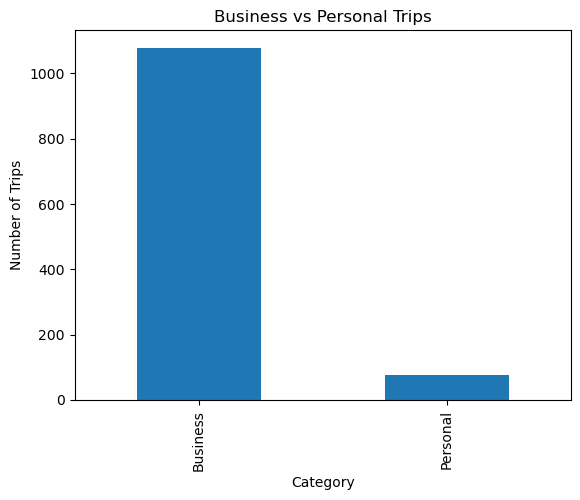

In [15]:
import matplotlib.pyplot as plt

category = df["CATEGORY"].value_counts()

category.plot(kind="bar")

plt.title("Business vs Personal Trips")
plt.xlabel("Category")
plt.ylabel("Number of Trips")

plt.show()

Business trips are much higher than personal trips.

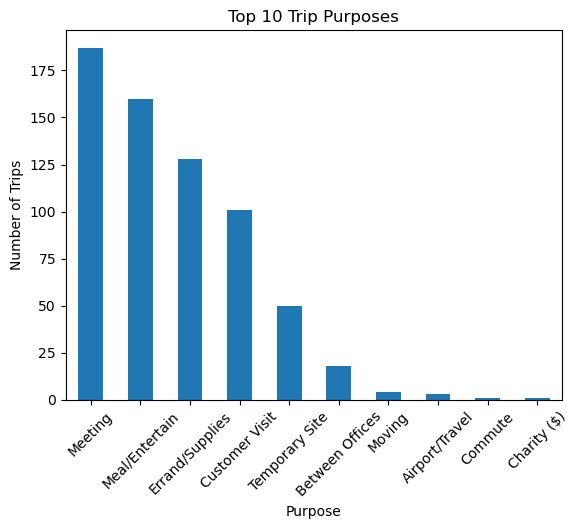

In [16]:
purpose = df["PURPOSE"].value_counts().head(10)

purpose.plot(kind="bar")

plt.title("Top 10 Trip Purposes")
plt.xlabel("Purpose")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)

plt.show()

Employees primarily use Uber for official work rather than personal travel.

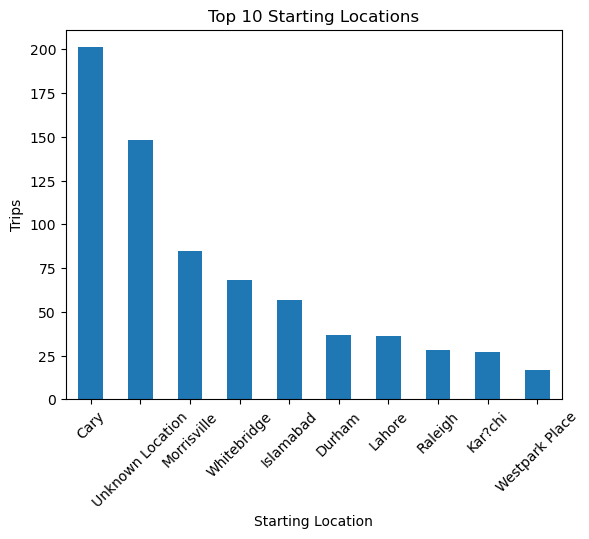

In [17]:
start = df["START"].value_counts().head(10)

start.plot(kind="bar")

plt.title("Top 10 Starting Locations")
plt.xlabel("Starting Location")
plt.ylabel("Trips")

plt.xticks(rotation=45)

plt.show()

The company can negotiate corporate ride plans with Uber to reduce travel expenses.

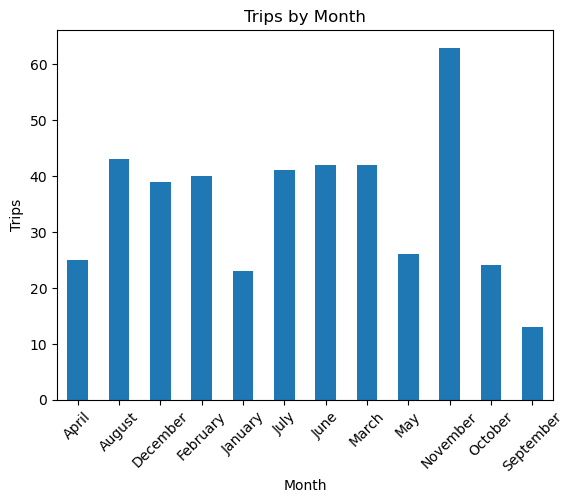

In [18]:
month = df["Month"].value_counts().sort_index()

month.plot(kind="bar")

plt.title("Trips by Month")
plt.xlabel("Month")
plt.ylabel("Trips")

plt.xticks(rotation=45)

plt.show()

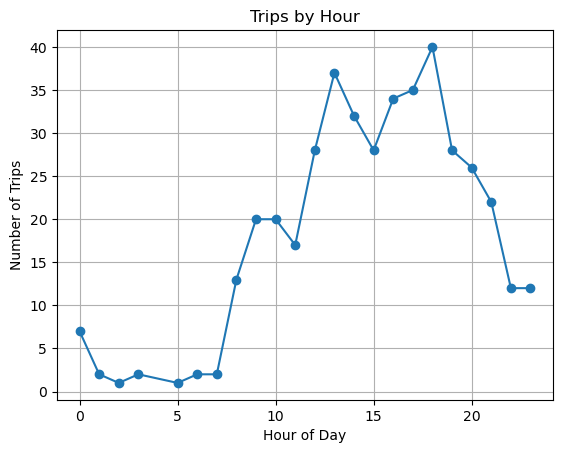

In [19]:
hour = df["Hour"].value_counts().sort_index()

hour.plot(kind="line", marker="o")

plt.title("Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.grid(True)

plt.show()

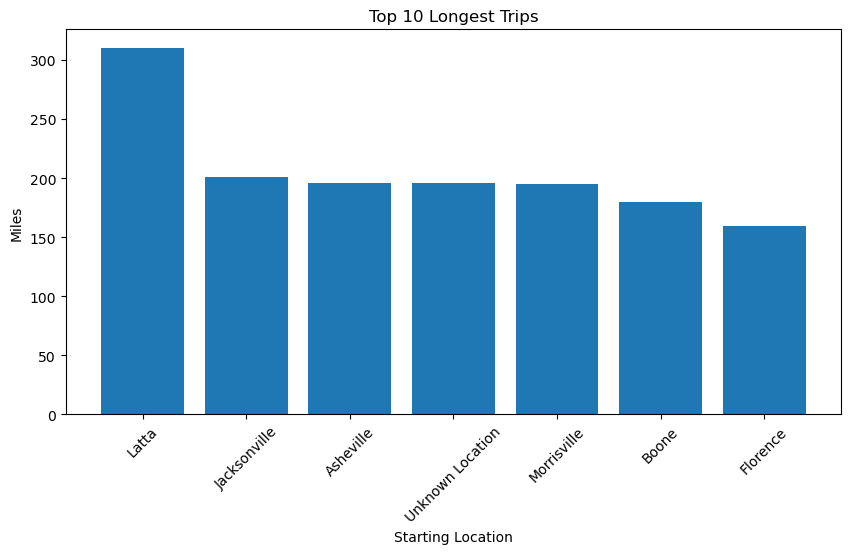

In [22]:
longest = df.nlargest(10, "MILES")

plt.figure(figsize=(10,5))

longest = longest.dropna(subset=["START", "MILES"]).copy()
longest["START"] = longest["START"].astype(str)

plt.bar(longest["START"], longest["MILES"])

plt.title("Top 10 Longest Trips")
plt.xlabel("Starting Location")
plt.ylabel("Miles")

plt.xticks(rotation=45)

plt.show()